# Comparative Ablation Study: Explainable Dueling Deep Reinforcement Learning for Dairy Supply Chain Optimization


This script executes a full comparative ablation study testing:

1. Full Model
2. Without GradNorm (Ordinary summed loss)
3. Without PER (Uniform sampling)
4. Without PAR (Raw unscaled reward)
5. Without Behavioural Cloning (Pure value learning)


In [1]:
import os
import time
import copy
import warnings
from pathlib import Path
import psutil

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import shap

warnings.filterwarnings("ignore")

## Configuration & Setup


In [2]:
OUTPUT_DIR = Path("./plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("./results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# Matplotlib styling for publication-quality figures
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

Using compute device: cuda


## Data Processing Pipeline


In [3]:
def load_and_preprocess_data():
    print("Loading dataset from Kaggle...")
    path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
    data_path = os.path.join(path, "train.csv")
    df = pd.read_csv(data_path)

    print("Processing temporal features...")
    date_cols = ["Date", "Production Date", "Expiration Date"]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

    df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days
    df = df[df["Days_to_Expiration"] >= 0].copy()
    df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

    MAX_SHELF_LIFE = 30
    fifo_matrix = df.pivot_table(
        index=["Date", "Product ID"],
        columns="Days_to_Expiration",
        values="Quantity in Stock (liters/kg)",
        aggfunc="sum",
        fill_value=0,
    )

    cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
    cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]
    if cols_to_group:
        fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
        fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

    fifo_matrix.columns = [
        f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
        for col in fifo_matrix.columns
    ]

    rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")
    rl_df.fillna(0, inplace=True)

    categorical_cols = [
        "Location",
        "Farm Size",
        "Product Name",
        "Brand",
        "Storage Condition",
        "Sales Channel",
    ]
    for col in categorical_cols:
        le = LabelEncoder()
        rl_df[col] = le.fit_transform(rl_df[col].astype(str))

    state_cols = [
        "Location",
        "Total Land Area (acres)",
        "Number of Cows",
        "Farm Size",
        "Product ID",
        "Product Name",
        "Brand",
        "Shelf Life (days)",
        "Storage Condition",
        "Quantity in Stock (liters/kg)",
        "Minimum Stock Threshold (liters/kg)",
        "Price per Unit",
        "Days_to_Expiration",
        "Product_Age_Days",
    ] + list(fifo_matrix.columns)

    action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

    scaler_S = StandardScaler()
    scaler_A = StandardScaler()

    S_raw = rl_df[state_cols].values
    A_raw = rl_df[action_cols].values
    S_matrix = scaler_S.fit_transform(S_raw)
    A_matrix = scaler_A.fit_transform(A_raw)

    # Financial Sub-Rewards
    rl_df["Gross_Profit"] = rl_df["Approx. Total Revenue(INR)"] - (
        rl_df["Quantity Sold (liters/kg)"] * rl_df["Price per Unit"]
    )
    waste_col = (
        "Stock_Expiring_in_0_Days"
        if "Stock_Expiring_in_0_Days" in rl_df.columns
        else "Stock_Expiring_in_1_Days"
    )
    rl_df["Waste_Penalty"] = rl_df[waste_col] * rl_df["Price per Unit"] * 1.5
    rl_df["Holding_Cost"] = (
        rl_df["Quantity in Stock (liters/kg)"] * rl_df["Price per Unit"] * 0.05
    )
    rl_df["Stockout_Penalty"] = np.where(
        rl_df["Quantity in Stock (liters/kg)"]
        < rl_df["Minimum Stock Threshold (liters/kg)"],
        (
            rl_df["Minimum Stock Threshold (liters/kg)"]
            - rl_df["Quantity in Stock (liters/kg)"]
        )
        * rl_df["Price per Unit"]
        * 2.0,
        0,
    )

    rl_df["Raw_Reward"] = (
        rl_df["Gross_Profit"]
        - rl_df["Waste_Penalty"]
        - rl_df["Holding_Cost"]
        - rl_df["Stockout_Penalty"]
    )

    r_median = rl_df["Raw_Reward"].median()
    r_std = rl_df["Raw_Reward"].std()
    rl_df["Bounded_Reward_PAR"] = (
        2 / (1 + np.exp(-2.0 * (rl_df["Raw_Reward"] - r_median) / r_std)) - 1
    )

    rl_df = rl_df.sort_values(by=["Location", "Product ID", "Date"]).reset_index(
        drop=True
    )
    S_raw = rl_df[state_cols].values
    S_matrix = scaler_S.transform(S_raw)
    A_matrix = scaler_A.transform(rl_df[action_cols].values)

    S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)
    is_terminal = (
        (rl_df["Product ID"] != rl_df["Product ID"].shift(-1))
        | (rl_df["Location"] != rl_df["Location"].shift(-1))
    ).values.copy()
    is_terminal[-1] = True

    return (
        rl_df,
        state_cols,
        action_cols,
        scaler_S,
        scaler_A,
        S_matrix,
        A_matrix,
        S_next_matrix,
        is_terminal,
    )

## RL Components


In [4]:
class OfflinePrioritizedReplayBuffer:
    def __init__(
        self, states, actions, rewards, next_states, dones, alpha=0.6, beta=0.4
    ):
        self.size = len(states)
        self.states = torch.tensor(states, dtype=torch.float32)
        self.actions = torch.tensor(actions, dtype=torch.float32)
        self.rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        self.next_states = torch.tensor(next_states, dtype=torch.float32)
        self.dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)
        self.alpha = alpha
        self.beta = beta
        self.priorities = np.ones(self.size, dtype=np.float32)

    def sample(self, batch_size):
        if self.alpha == 0.0:
            probs = np.ones(self.size) / self.size
        else:
            probs = self.priorities**self.alpha
            probs /= probs.sum()

        indices = np.random.choice(self.size, batch_size, p=probs, replace=False)

        if self.beta == 0.0:
            weights = np.ones((batch_size, 1), dtype=np.float32)
        else:
            total = self.size
            weights = (total * probs[indices]) ** (-self.beta)
            weights /= weights.max()
            weights = np.expand_dims(weights, 1)

        return (
            self.states[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_states[indices],
            self.dones[indices],
            indices,
            torch.FloatTensor(weights),
        )

    def update_priorities(self, indices, td_errors, offset=1e-5):
        if self.alpha > 0.0:
            for idx, error in zip(indices, td_errors):
                self.priorities[idx] = abs(error) + offset


class DuelingMultiHeadNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DuelingMultiHeadNetwork, self).__init__()
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, action_dim)
        )
        self.task_weights = nn.Parameter(torch.ones(2, dtype=torch.float32))

    def forward(self, state):
        shared_features = self.shared_layers(state)
        V = self.value_stream(shared_features)
        A = self.advantage_stream(shared_features)
        Q = V + (A - A.mean(dim=1, keepdim=True))
        return Q, V, A


class GradientSurgeryManager:
    def __init__(self, model, alpha=0.16):
        self.model = model
        self.alpha = alpha
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-3)
        self.weight_optimizer = optim.Adam([self.model.task_weights], lr=1e-3)

    def compute_grad_norm(self, loss_v, loss_a):
        task_losses = torch.stack([loss_v, loss_a])
        last_shared_layer = self.model.shared_layers[-2].weight

        grad_v = torch.autograd.grad(
            task_losses[0], last_shared_layer, retain_graph=True, create_graph=True
        )[0]
        grad_a = torch.autograd.grad(
            task_losses[1], last_shared_layer, retain_graph=True, create_graph=True
        )[0]

        norm_v = torch.norm(grad_v * self.model.task_weights[0])
        norm_a = torch.norm(grad_a * self.model.task_weights[1])
        norms = torch.stack([norm_v, norm_a])

        mean_norm = norms.mean().detach()
        target_norms = mean_norm * (task_losses.detach() ** self.alpha)
        return torch.sum(torch.abs(norms - target_norms))

## Training & Evaluation Engine


In [5]:
def train_and_evaluate_ablation(config, env_data):
    print(f"\nStarting Experiment: {config['name']}...")
    torch.manual_seed(42)
    np.random.seed(42)

    (
        rl_df,
        state_cols,
        action_cols,
        scaler_S,
        scaler_A,
        S_matrix,
        A_matrix,
        S_next_matrix,
        is_terminal,
    ) = env_data

    # Apply PAR Ablation
    if config["use_par"]:
        R_matrix = rl_df["Bounded_Reward_PAR"].values
    else:
        R_matrix = rl_df["Raw_Reward"].values

    # Apply PER Ablation
    alpha = 0.6 if config["use_per"] else 0.0
    beta = 0.4 if config["use_per"] else 0.0

    buffer = OfflinePrioritizedReplayBuffer(
        S_matrix, A_matrix, R_matrix, S_next_matrix, is_terminal, alpha=alpha, beta=beta
    )

    STATE_DIM = S_matrix.shape[1]
    ACTION_DIM = A_matrix.shape[1]

    model = DuelingMultiHeadNetwork(STATE_DIM, ACTION_DIM).to(device)
    target_model = copy.deepcopy(model).to(device)
    for p in target_model.parameters():
        p.requires_grad = False

    grad_surgery = GradientSurgeryManager(model)
    if not config["use_gradnorm"]:
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

    BATCH_SIZE = 2048
    EPOCHS = 15
    GAMMA = 0.99
    TAU = 0.005
    steps_per_epoch = buffer.size // BATCH_SIZE

    reward_threshold = np.percentile(R_matrix, 30)
    history = {"critic_loss": [], "actor_loss": [], "total_loss": [], "grad_loss": []}

    start_time = time.time()

    model.train()
    for epoch in range(EPOCHS):
        e_c_loss, e_a_loss, e_t_loss, e_g_loss = 0, 0, 0, 0

        for _ in range(steps_per_epoch):
            s, a, r, s_next, d, idxs, weights = buffer.sample(BATCH_SIZE)
            s, a, r, s_next, d, weights = (
                s.to(device),
                a.to(device),
                r.to(device),
                s_next.to(device),
                d.to(device),
                weights.to(device),
            )

            with torch.no_grad():
                _, V_next_target, _ = target_model(s_next)
                td_target = r + GAMMA * V_next_target * (1 - d)

            _, V_pred, Pred_A = model(s)
            td_errors = td_target - V_pred
            loss_v = (weights * (td_errors**2)).mean()

            # Apply Behavioural Cloning Ablation
            if config["use_bc"]:
                good_action_mask = (r >= reward_threshold).float()
                loss_a = (weights * good_action_mask * ((Pred_A - a) ** 2)).mean()
            else:
                loss_a = torch.tensor(0.0, device=device, requires_grad=True)

            # Apply GradNorm Ablation
            if config["use_gradnorm"] and config["use_bc"]:
                grad_surgery.optimizer.zero_grad()
                grad_surgery.weight_optimizer.zero_grad()
                weighted_loss = (model.task_weights[0] * loss_v) + (
                    model.task_weights[1] * loss_a
                )
                grad_loss = grad_surgery.compute_grad_norm(loss_v, loss_a)
                total_loss = weighted_loss + grad_loss
                total_loss.backward()
                grad_surgery.optimizer.step()
                grad_surgery.weight_optimizer.step()
            else:
                if not config["use_gradnorm"]:
                    optimizer.zero_grad()
                else:
                    grad_surgery.optimizer.zero_grad()

                total_loss = loss_v + loss_a
                grad_loss = torch.tensor(0.0)
                total_loss.backward()

                if not config["use_gradnorm"]:
                    optimizer.step()
                else:
                    grad_surgery.optimizer.step()

            buffer.update_priorities(idxs, td_errors.detach().cpu().numpy().flatten())

            for target_param, model_param in zip(
                target_model.parameters(), model.parameters()
            ):
                target_param.data.copy_(
                    TAU * model_param.data + (1.0 - TAU) * target_param.data
                )

            e_c_loss += loss_v.item()
            e_a_loss += loss_a.item() if config["use_bc"] else 0.0
            e_t_loss += total_loss.item()
            e_g_loss += grad_loss.item()

        history["critic_loss"].append(e_c_loss / steps_per_epoch)
        history["actor_loss"].append(e_a_loss / steps_per_epoch)
        history["total_loss"].append(e_t_loss / steps_per_epoch)
        history["grad_loss"].append(e_g_loss / steps_per_epoch)

    train_time = time.time() - start_time
    memory_used = (
        torch.cuda.max_memory_allocated() / (1024**2)
        if torch.cuda.is_available()
        else psutil.Process().memory_info().rss / (1024**2)
    )
    convergence_epoch = np.argmin(history["critic_loss"]) + 1

    # Evaluation Metrics
    model.eval()
    with torch.no_grad():
        S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
        _, _, A_pred_tensor = model(S_tensor)
        A_pred_scaled = A_pred_tensor.cpu().numpy()

    A_true_real = scaler_A.inverse_transform(A_matrix)
    A_pred_real = scaler_A.inverse_transform(A_pred_scaled)

    mae = mean_absolute_error(A_true_real, A_pred_real)
    mse = mean_squared_error(A_true_real, A_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(A_true_real, A_pred_real)
    evs = explained_variance_score(A_true_real, A_pred_real)

    nrmse_p = np.sqrt(mean_squared_error(A_true_real[:, 0], A_pred_real[:, 0])) / (
        A_true_real[:, 0].max() - A_true_real[:, 0].min()
    )
    nrmse_r = np.sqrt(mean_squared_error(A_true_real[:, 1], A_pred_real[:, 1])) / (
        A_true_real[:, 1].max() - A_true_real[:, 1].min()
    )
    acc = (max(0, (1 - nrmse_p) * 100) + max(0, (1 - nrmse_r) * 100)) / 2

    return (
        {
            "Config": config["name"],
            "Critic Loss": history["critic_loss"][-1],
            "Actor Loss": history["actor_loss"][-1],
            "Total Loss": history["total_loss"][-1],
            "GradNorm Loss": history["grad_loss"][-1],
            "Training Time (s)": train_time,
            "Memory (MB)": memory_used,
            "Convergence Epoch": convergence_epoch,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Explained Variance": evs,
            "Accuracy (%)": acc,
            "Avg Bounded Reward": R_matrix.mean(),
        },
        history,
        model,
    )

## Experiment Execution & Visualization


In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns


def generate_visualizations(results_df, histories):
    print("\nGenerating comparative visualizations...")

    # Create output directory if it doesn't exist
    os.makedirs("./plots", exist_ok=True)

    # 1. Individual Bar Charts for Each Metric
    metrics_to_plot = [
        "Accuracy (%)",
        "MAE",
        "RMSE",
        "R2",
        "Training Time (s)",
        "Memory (MB)",
    ]

    colors = sns.color_palette("husl", len(results_df))

    for metric in metrics_to_plot:
        plt.figure(figsize=(8, 6))

        sns.barplot(
            x="Config",
            y=metric,
            data=results_df,
            palette=colors,
        )

        plt.title(f"Comparison: {metric}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        # Create a filename without special characters
        filename = (
            metric.replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("%", "Percent")
            .replace("/", "_")
        )

        plt.savefig(f"./plots/Ablation_Study_{filename}_Comparison.pdf", dpi=1200)
        plt.show()
        plt.close()

    # 2. Individual Critic Loss Plot
    plt.figure(figsize=(8, 6))

    for name, hist in histories.items():
        plt.plot(hist["critic_loss"], label=name)

    plt.title("Critic Loss Convergence")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("./plots/Ablation_Study_Critic_Loss_Convergence.pdf", dpi=1200)
    plt.show()
    plt.close()

    # 3. Individual Actor Loss Plot
    plt.figure(figsize=(8, 6))

    for name, hist in histories.items():
        plt.plot(hist["actor_loss"], label=name)

    plt.title("Actor Loss Convergence (Behavioural Cloning)")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("./plots/Ablation_Study_Actor_Loss_Convergence.pdf", dpi=1200)
    plt.show()
    plt.close()


def generate_report(results_df):
    results_df = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(
        drop=True
    )

    best_config = results_df.iloc[0]["Config"]
    worst_config = results_df.iloc[-1]["Config"]

    baseline_acc = results_df[results_df["Config"] == "Full Model"][
        "Accuracy (%)"
    ].values[0]

    print("Ablation Study Analysis:")
    print(
        f"\tBest Performing Configuration: {best_config} "
        f"({results_df.iloc[0]['Accuracy (%)']:.2f}% Accuracy)"
    )
    print(
        f"\tWorst Performing Configuration: {worst_config} "
        f"({results_df.iloc[-1]['Accuracy (%)']:.2f}% Accuracy)"
    )
    print(f"\tDueling DRL (Baseline Model) Accuracy: {baseline_acc:.2f}%")

## Explainability Pipeline (XAI)


In [7]:
def run_explainability_pipeline(best_model, env_data):
    print("\nRunning Explainability (XAI) Pipeline on Best Model...")
    rl_df, state_cols, action_cols, scaler_S, scaler_A, S_matrix, A_matrix, _, _ = (
        env_data
    )

    # 1. SHAP Local Explanations
    class ActionStreamWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model(x)[2]

    action_model = ActionStreamWrapper(best_model).to(device).eval()
    background_tensor = torch.tensor(S_matrix[:200], dtype=torch.float32).to(device)
    test_tensor = torch.tensor(S_matrix[:5], dtype=torch.float32).to(device)

    explainer = shap.GradientExplainer(action_model, background_tensor)
    shap_values = explainer.shap_values(test_tensor)
    if not isinstance(shap_values, list):
        shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

    print("SHAP calculations completed.")

    # 2. Symbolic Decision Trees (Global Proxy)
    best_model.eval()
    with torch.no_grad():
        _, _, A_pred_scaled = best_model(
            torch.tensor(S_matrix, dtype=torch.float32).to(device)
        )
    A_pred_real = scaler_A.inverse_transform(A_pred_scaled.cpu().numpy())

    dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
    dt_price.fit(rl_df[state_cols], A_pred_real[:, 0])
    print(
        f"Global Pricing Surrogate Tree R2 Fidelity: {dt_price.score(rl_df[state_cols], A_pred_real[:, 0]):.4f}"
    )

    # 3. Reward Decomposition Surrogate
    X_hist = np.hstack([S_matrix, A_matrix])
    Y_hist = rl_df[
        ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
    ].values

    rf = RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42, n_jobs=-1)
    rf.fit(X_hist, Y_hist)
    print("Reward Decomposition Surrogate trained.")

## Main Execution


Loading dataset from Kaggle...
Processing temporal features...

Starting Experiment: Full Model...

Starting Experiment: Without GradNorm...

Starting Experiment: Without PER...

Starting Experiment: Without PAR...

Starting Experiment: Without BC...

Generating comparative visualizations...


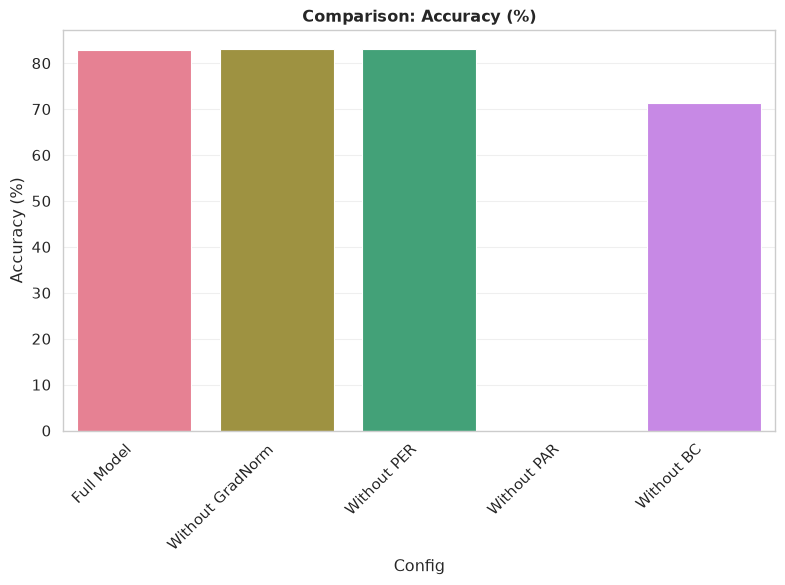

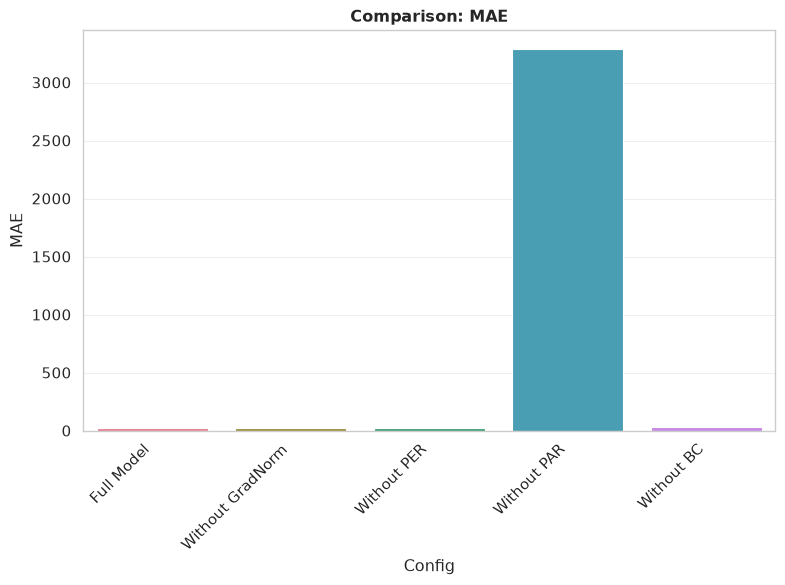

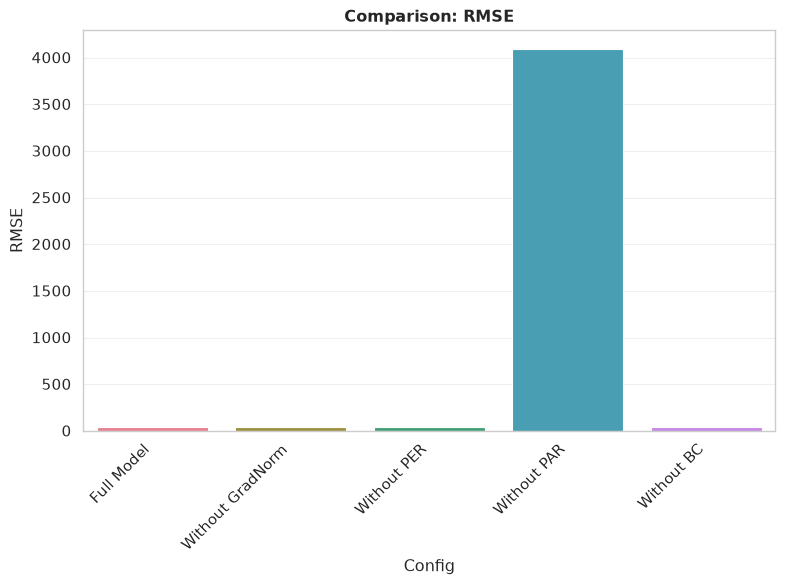

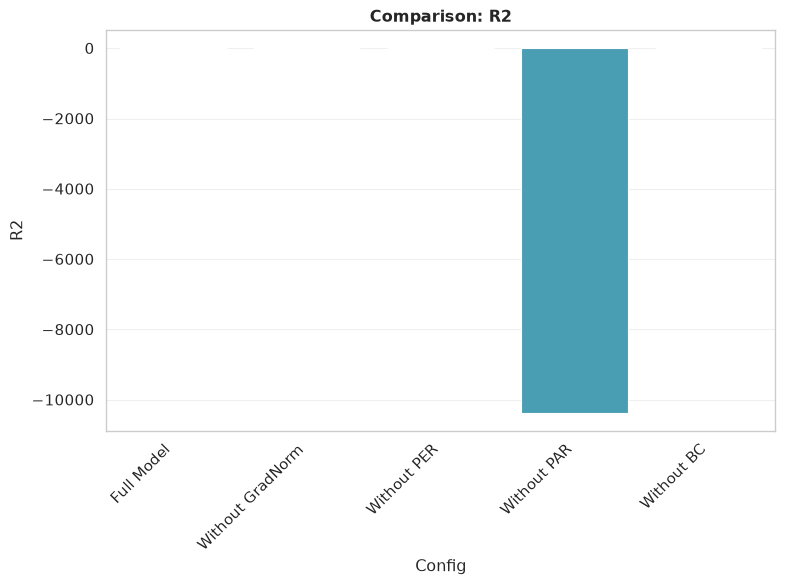

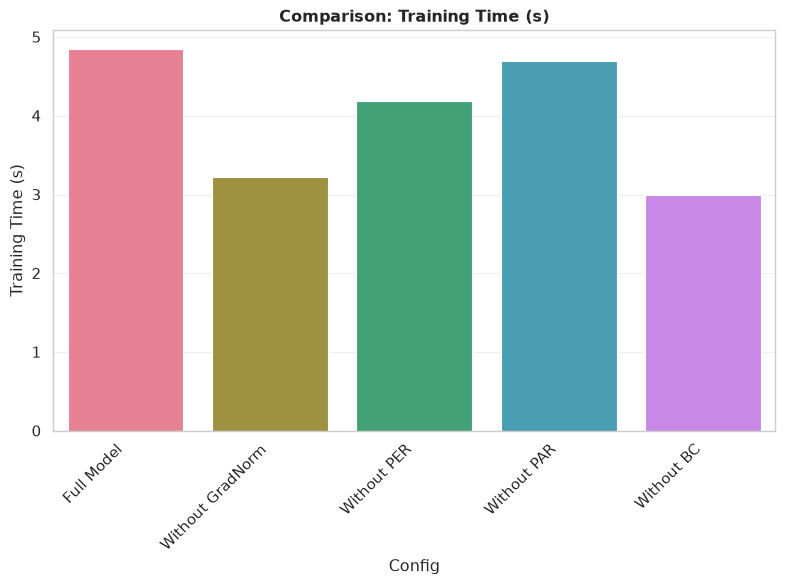

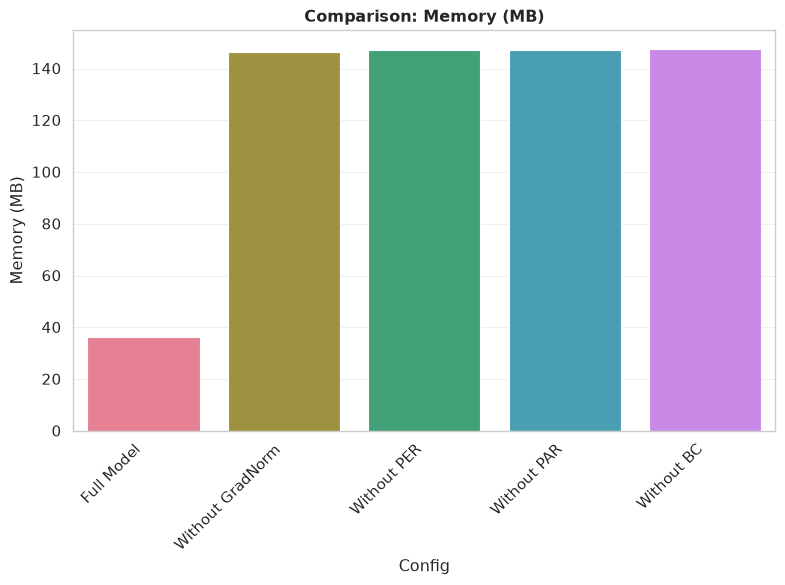

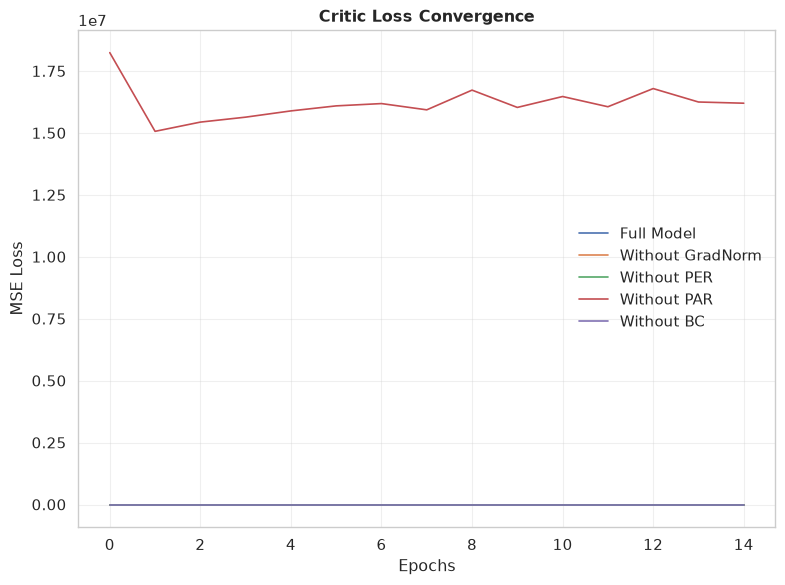

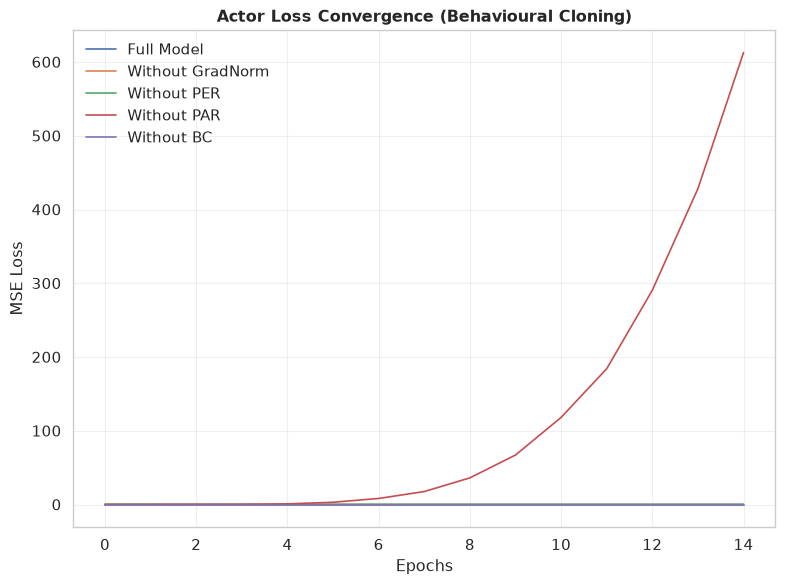

Ablation Study Analysis:
	Best Performing Configuration: Without GradNorm (83.11% Accuracy)
	Worst Performing Configuration: Without PAR (0.00% Accuracy)
	Dueling DRL (Baseline Model) Accuracy: 82.98%

Running Explainability (XAI) Pipeline on Best Model...
SHAP calculations completed.
Global Pricing Surrogate Tree R2 Fidelity: 0.9694
Reward Decomposition Surrogate trained.

[SUCCESS] Ablation Study completed. All outputs saved to './plots' and './results'.


In [8]:
if __name__ == "__main__":
    env_data = load_and_preprocess_data()

    configs = [
        {
            "name": "Full Model",
            "use_gradnorm": True,
            "use_per": True,
            "use_par": True,
            "use_bc": True,
        },
        {
            "name": "Without GradNorm",
            "use_gradnorm": False,
            "use_per": True,
            "use_par": True,
            "use_bc": True,
        },
        {
            "name": "Without PER",
            "use_gradnorm": True,
            "use_per": False,
            "use_par": True,
            "use_bc": True,
        },
        {
            "name": "Without PAR",
            "use_gradnorm": True,
            "use_per": True,
            "use_par": False,
            "use_bc": True,
        },
        {
            "name": "Without BC",
            "use_gradnorm": True,
            "use_per": True,
            "use_par": True,
            "use_bc": False,
        },
    ]

    all_results = []
    all_histories = {}
    best_model_ref = None
    best_acc = -1

    for config in configs:
        stats, history, model = train_and_evaluate_ablation(config, env_data)
        all_results.append(stats)
        all_histories[config["name"]] = history

        if stats["Accuracy (%)"] > best_acc:
            best_acc = stats["Accuracy (%)"]
            best_model_ref = model

    # Tables & Exports
    ablation_study_df = pd.DataFrame(all_results)

    # Calculate Relative Drop vs Full Model
    baseline_acc = ablation_study_df[ablation_study_df["Config"] == "Full Model"][
        "Accuracy (%)"
    ].values[0]
    ablation_study_df["Relative Degradation (%)"] = (
        (ablation_study_df["Accuracy (%)"] - baseline_acc) / baseline_acc
    ) * 100

    ablation_study_df.to_csv("./results/Ablation_Study_Results.csv", index=False)
    ablation_study_df

    # Visualizations & Report
    generate_visualizations(ablation_study_df, all_histories)
    generate_report(ablation_study_df)

    # Execute XAI on the Best Configuration
    run_explainability_pipeline(best_model_ref, env_data)
    print(
        "\n[SUCCESS] Ablation Study completed. All outputs saved to './plots' and './results'."
    )

In [9]:
ablation_study_df

,Config,Critic Loss,Actor Loss,Total Loss,GradNorm Loss,Training Time (s),Memory (MB),Convergence Epoch,MAE,MSE,RMSE,R2,Explained Variance,Accuracy (%),Avg Bounded Reward,Relative Degradation (%)
0,Full Model,6.282566e-02,0.089649,5.106429e-02,0.000236,4.846230,36.255859,14,24.204866,1.344048e+03,36.661262,0.484620,0.484846,82.984633,-0.048919,0.000000
1,Without GradNorm,6.425523e-02,0.094725,1.589803e-01,0.000000,3.227286,146.532715,12,24.008787,1.333273e+03,36.514010,0.489362,0.489633,83.105678,-0.048919,0.145865
2,Without PER,1.695855e-01,0.355178,1.183538e-01,0.000409,4.193341,147.009766,13,24.158253,1.340180e+03,36.608464,0.486457,0.487088,83.039484,-0.048919,0.066098
3,Without PAR,1.620797e+07,612.845039,3.385008e+06,145947.543912,4.699303,147.012695,2,3288.647433,1.673598e+07,4090.963744,-10364.775729,-3156.663493,0.000000,-2024.795992,-100.000000
4,Without BC,5.654169e-02,0.000000,5.654169e-02,0.000000,2.989314,147.493164,15,34.394990,1.756572e+03,41.911473,-0.057516,-0.052318,71.469748,-0.048919,-13.875924
